# Datatypes scikit-image
| **Tipo de dato** | **Rango de valores**                    |
|---|---|
| `uint8`          | 0 a 255                                 |
| `uint16`         | 0 a 65535                               |
| `uint32`         | 0 a 2<sup>32</sup> - 1                 |
| `float`          | -1 a 1 o 0 a 1 |
| `int8`           | -128 a 127                              |
| `int16`          | -32768 a 32767                          |
| `int32`          | -2<sup>31</sup> a 2<sup>31</sup> - 1   |

Data type: uint8
Min: 0
Max: 255

Data type: float64
Min: 0.0
Max: 0.1293114584528271



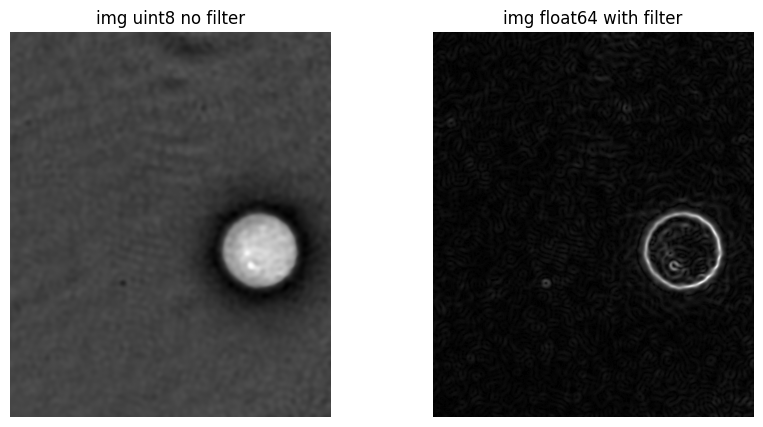

In [14]:
from skimage import data, filters, color, feature
import numpy as np
import matplotlib.pyplot as plt

def printInfo(img):
    print(f"Data type: {img.dtype}")
    print(f"Min: {np.min(img)}")
    print(f"Max: {np.max(img)}")
    print()

img = data.cell()


printInfo(img)

# Skimage filter
filtered_img = filters.sobel(img)

printInfo(filtered_img)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].set_title('img uint8 no filter')
ax[0].axis('off')
ax[0].imshow(img, cmap='gray')

ax[1].set_title('img float64 with filter')
ax[1].axis('off')
ax[1].imshow(filtered_img, cmap='gray')

plt.show()

Data type: uint8
Min: 0
Max: 255

Data type: float64
Min: 0.0
Max: 1.0



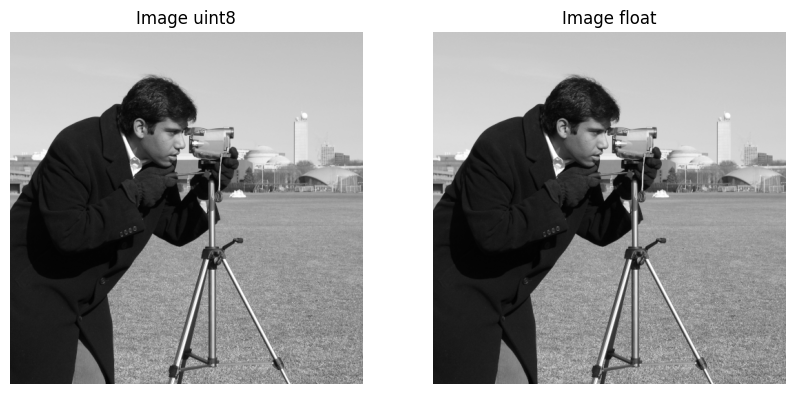

In [15]:
from skimage import data, filters, util
import numpy as np
import matplotlib.pyplot as plt

img = data.camera()

printInfo(img)

# Change data type
imgFloat = util.img_as_float(img)

printInfo(imgFloat)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].set_title('Image uint8')
ax[0].axis('off')
ax[0].imshow(img, cmap='gray')

ax[1].set_title('Image float')
ax[1].axis('off')
ax[1].imshow(imgFloat, cmap='gray')

plt.show()

Data type: uint8
Min: 0
Max: 255

Data type: float64
Min: 0.0
Max: 1.0

Data type: float64
Min: 0.0
Max: 255.0



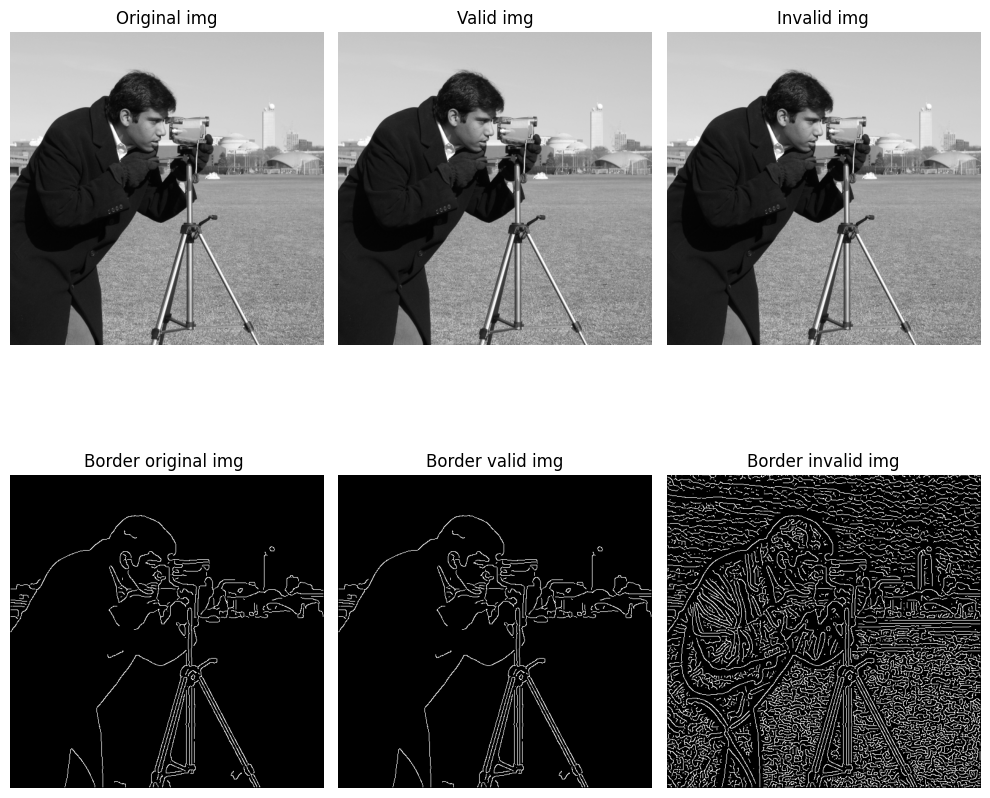

In [23]:
from skimage import data, filters, util, feature
import numpy as np
import matplotlib.pyplot as plt

img = data.camera()
printInfo(img)

# Correct conversion to float (rescaling)
validFloatImg = util.img_as_float(img)
printInfo(validFloatImg)

# Correct conversion to float (no rescaling)
invalidFloatImg = img.astype(float)
printInfo(invalidFloatImg)

# Aply Canny (find borders)
originalImgBorder = feature.canny(img, sigma=2)
validImgBorder = feature.canny(validFloatImg, sigma=2)
invalidImgBorder = feature.canny(invalidFloatImg, sigma=2)

fig, ax = plt.subplots(2, 3, figsize=(10, 10))

ax[0][0].set_title('Original img')
ax[0][0].axis('off')
ax[0][0].imshow(img, cmap='gray')

ax[0][1].set_title('Valid img')
ax[0][1].axis('off')
ax[0][1].imshow(validFloatImg, cmap='gray')

ax[0][2].set_title('Invalid img')
ax[0][2].axis('off')
ax[0][2].imshow(invalidFloatImg, cmap='gray')

ax[1][0].set_title('Border original img ')
ax[1][0].axis('off')
ax[1][0].imshow(originalImgBorder, cmap='gray')

ax[1][1].set_title('Border valid img')
ax[1][1].axis('off')
ax[1][1].imshow(validImgBorder, cmap='gray')

ax[1][2].set_title('Border invalid img')
ax[1][2].axis('off')
ax[1][2].imshow(invalidImgBorder, cmap='gray')
plt.tight_layout()
plt.show()

Why seems right on the image but not the borders
Even it can be printed correctly the image, the algorithm its after the change between values, lets see them

In [29]:
print(img[15][15])
print(validFloatImg[15][15])
print(invalidFloatImg[15][15])

200
0.7843137254901961
200.0


The algorithm sees float and its tuned to work correctly in 0-1

## Some conversion conventions

In [31]:
from skimage import data, util
import numpy as np

negativeArray = np.asarray([[-128, -75, -20],[0, 50, 75],[100, 115, 127]], dtype=np.int8)
print(f"Aarray (int8): \n {negativeArray}")

unsignedArray = util.img_as_ubyte(negativeArray) # Negative values turn 0

print()
print(f"Array (Uint8): \n {unsignedArray}")

Aarray (int8): 
 [[-128  -75  -20]
 [   0   50   75]
 [ 100  115  127]]

Array (Uint8): 
 [[  0   0   0]
 [  0 100 151]
 [201 231 255]]


In [ ]:
from skimage import data, util
import numpy as np

# Float array (64 bits)
floatArray = np.array([0, 0.5, 0.503, 1], dtype=float)
print(f"Array (Float): {floatArray}")

# Uint8 Array (8 bits)
# Now 0.5 and 0.503 have the same value
uint8Array = util.img_as_ubyte(floatArray)
print(f"Array (Uint8): {uint8Array}")

Array (Float): [0.    0.5   0.503 1.   ]
Array (Uint8): [  0 128 128 255]
